# Noisy-channel Bayesian activation-patching artifact explorer (reasoning off)

This is the reasoning-off, single-presentation counterpart of notebook 14. It reads the 5,120 completed Qwen3.5-9B transcript rows generated for the activation-patching experiment and never changes the source artifact. The run crosses 64 question sets, all eight answer patterns, and 10 interior shared-reliability values. Every row has `reasoning=False` and presentation order `C1_C2`.

The notebook retains notebook 14's transcript inspection, error audit, endpoint audit, calibration metrics, reliability plots, conditional selection queries, and reusable SQL recipes. Position-balanced and reasoning-paired statistics are explicitly marked unavailable because the source run contains neither swapped presentations nor reasoning-on rows. All SQL tables are derived in memory from a source file opened read-only.

The semantic answer-surface contrast used throughout is

\[
z = \operatorname{logit}(C_1)-\operatorname{logit}(C_2),
\qquad q_{\mathrm{LLM}}=\sigma(z).
\]

In [1]:
from __future__ import annotations

import math
import sys
from collections import defaultdict
from pathlib import Path
from pprint import pprint
from statistics import fmean

import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from noisy_channel_artifact_explorer import SQLResult, load_transcript_explorer

MODEL_KEY = "Qwen_Qwen3.5-9B_4c87a623"
RUN_ID = "qwen35_9b_n9_k3_r10_s64_selected_tokens_v2_reasoning_off"
RESULTS_PATH = (
    REPO_ROOT
    / "artifacts"
    / "noisy_channel_bayesian_experiment_2_activation_patching"
    / MODEL_KEY
    / "runs"
    / RUN_ID
    / "results.jsonl"
)
explorer = load_transcript_explorer(RESULTS_PATH)

assert len(explorer.transcript_rows) == 5_120
assert {bool(row["reasoning"]) for row in explorer.transcript_rows} == {False}
assert {row["presentation_order"] for row in explorer.transcript_rows} == {"C1_C2"}
assert explorer.table_names() == ("transcript_rows",)

reliability_order = [
    row["reliability_exact"]
    for row in explorer.sql("""
        SELECT reliability_exact
        FROM transcript_rows
        GROUP BY reliability_exact
        ORDER BY reliability
    """)
]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 115,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

explorer.summary()

{'source': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_2_activation_patching/Qwen_Qwen3.5-9B_4c87a623/runs/qwen35_9b_n9_k3_r10_s64_selected_tokens_v2_reasoning_off/results.jsonl',
 'artifact_mode': 'read-only source; in-memory SQLite derivatives',
 'transcript_rows': 5120,
 'balanced_rows': 0,
 'reasoning_pairs': 0,
 'models': ['Qwen/Qwen3.5-9B'],
 'reliabilities': ['1/20',
  '1/4',
  '11/20',
  '13/20',
  '17/20',
  '19/20',
  '3/20',
  '3/4',
  '7/20',
  '9/20'],
 'missing_answer_boundary_logits': 0}

## Column model and query semantics

`transcript_rows` contains all presentation-level fields from notebook 14: question set, answer pattern, membership subsets, reports, agreement vectors and totals, likelihoods, posteriors, raw answer-surface logits, generated choice, correctness, and compliance. There are no derived `balanced_rows` or `reasoning_pairs` tables for this run.

Use `explorer.sql(...)` for SQLite or the immutable Python query builder. SQLite uses 0/1 for booleans and `?` placeholders for parameters. Here, every \(q\) is the probability assigned to semantic C1 (candidate value 2), while C2 is candidate value 7.

In [2]:
display(explorer.sql("""
SELECT
    COUNT(*) AS transcript_rows,
    COUNT(DISTINCT question_set_index) AS question_sets,
    COUNT(DISTINCT answer_pattern_index) AS answer_patterns,
    COUNT(DISTINCT reliability_exact) AS reliability_values,
    COUNT(DISTINCT presentation_order) AS presentation_orders,
    SUM(answer_boundary_available) AS rows_with_boundary_logits,
    SUM(semantic_answer_compliance) AS semantically_compliant_rows
FROM transcript_rows
"""))

# Uncomment for the full scalar column inventory.
# display(explorer.columns("transcript_rows"))

transcript_rows,question_sets,answer_patterns,reliability_values,presentation_orders,rows_with_boundary_logits,semantically_compliant_rows
5120,64,8,10,1,5120,5120


In [3]:
summary_by_reliability = explorer.sql("""
SELECT
    reliability_exact,
    reliability,
    COUNT(*) AS n,
    SUM(q_true IS NOT NULL AND ABS(q_true - 0.5) > 1e-12) AS scored_targets,
    SUM(canonical_posterior_correct IS NOT NULL) AS scored_emitted_choices,
    AVG(canonical_posterior_correct) AS emitted_choice_accuracy,
    AVG(logit_correct) AS boundary_logit_accuracy,
    AVG(semantic_answer_compliance) AS semantic_compliance,
    AVG(answer_boundary_available) AS boundary_availability,
    AVG(z) AS mean_z,
    AVG(q_true) AS mean_q_true,
    AVG(q_llm) AS mean_q_llm,
    AVG(q_llm - q_true) AS mean_calibration_error
FROM transcript_rows
GROUP BY reliability_exact, reliability
ORDER BY reliability
""")
display(summary_by_reliability)

reliability_exact,reliability,n,scored_targets,scored_emitted_choices,emitted_choice_accuracy,boundary_logit_accuracy,semantic_compliance,boundary_availability,mean_z,mean_q_true,mean_q_llm,mean_calibration_error
1/20,0.05,512,336,336,0.33630952380952384,0.35119047619047616,1.0,1.0,-0.490234375,0.5,0.3858287918491612,-0.1141712081508388
3/20,0.15,512,336,336,0.31845238095238093,0.3541666666666667,1.0,1.0,-0.433837890625,0.5,0.3981017178373217,-0.10189828216267834
1/4,0.25,512,336,336,0.33035714285714285,0.3630952380952381,1.0,1.0,-0.46630859375,0.5,0.3904511050116534,-0.1095488949883466
7/20,0.35,512,336,336,0.3125,0.3541666666666667,1.0,1.0,-0.46533203125,0.5,0.3910374172221589,-0.10896258277784109
9/20,0.45,512,336,336,0.31845238095238093,0.35119047619047616,1.0,1.0,-0.4775390625,0.5,0.38854825564213896,-0.11145174435786104
11/20,0.55,512,336,336,0.7529761904761905,0.7053571428571429,1.0,1.0,-0.39208984375,0.5,0.4091453574859706,-0.09085464251402943
13/20,0.65,512,336,336,0.7470238095238095,0.7083333333333334,1.0,1.0,-0.3798828125,0.5,0.41210595229412494,-0.08789404770587504
3/4,0.75,512,336,336,0.7559523809523809,0.7351190476190477,1.0,1.0,-0.317138671875,0.5,0.42622542886644754,-0.07377457113355246
17/20,0.85,512,336,336,0.7827380952380952,0.7321428571428571,1.0,1.0,-0.322509765625,0.5,0.4254368873921711,-0.07456311260782889
19/20,0.95,512,336,336,0.7916666666666666,0.7410714285714286,1.0,1.0,-0.2958984375,0.5,0.43187401985440216,-0.06812598014559781


In [4]:
# Same direct-SQL exploration style as notebook 14.
display(explorer.sql("""
SELECT
    row_id,
    question_set_index,
    answer_pattern,
    question_subsets_json,
    observed_reports_json,
    reliability_exact,
    total_agreement_candidate_1,
    total_agreement_candidate_2,
    candidate_1_likelihood_total,
    candidate_2_likelihood_total,
    candidate_1_posterior,
    candidate_2_posterior,
    q_true,
    candidate_1_raw_logit,
    candidate_2_raw_logit,
    z,
    q_llm,
    model_choice_canonical,
    canonical_posterior_correct
FROM transcript_rows
ORDER BY ABS(z) DESC
LIMIT 12
"""))

row_id,question_set_index,answer_pattern,question_subsets_json,observed_reports_json,reliability_exact,total_agreement_candidate_1,total_agreement_candidate_2,candidate_1_likelihood_total,candidate_2_likelihood_total,candidate_1_posterior,candidate_2_posterior,q_true,candidate_1_raw_logit,candidate_2_raw_logit,z,q_llm,model_choice_canonical,canonical_posterior_correct
7bc8cc64de85952a9a8b84ea,6,NNN,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",19/20,3,0,0.8573749999999999,0.00012500000000000033,0.2465581077680722,3.5946655163737015e-05,0.9998542274052478,24.0,21.625,2.375,0.9149009549929797,C1,1
974f0e52c70bd12112d4b9ca,6,NNN,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",9/20,3,0,0.09112500000000001,0.16637500000000005,0.08201147485656429,0.14973562830464618,0.3538834951456311,23.75,21.625,2.125,0.8933094060543487,C1,0
c65bece2742e1b45f4d46de5,6,NNN,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",13/20,3,0,0.27462500000000006,0.04287499999999999,0.18879436280828393,0.029474950588639685,0.8649606299212598,23.75,21.625,2.125,0.8933094060543487,C1,1
aab132839a129087bc9b6a9a,13,NNN,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",13/20,0,3,0.04287499999999999,0.27462500000000006,0.03141888797288633,0.20124576348813777,0.13503937007874015,21.25,23.375,-2.125,0.10669059394565118,C2,1
996b5f3823be526b7742bf88,6,NNN,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",17/20,3,0,0.6141249999999999,0.0033750000000000013,0.236736857321833,0.0013010167204741483,0.9945344129554656,23.875,21.75,2.125,0.8933094060543487,C1,1
c9aabb9909ca91aebfe4a50a,13,NNN,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",17/20,0,3,0.0033750000000000013,0.6141249999999999,0.0016039921582605597,0.2918671656864492,0.0054655870445344135,21.5,23.625,-2.125,0.10669059394565118,C2,1
2afcd903424f949fb59f6865,13,NNN,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",19/20,0,3,0.00012500000000000033,0.8573749999999999,4.686255213458925e-05,0.32143024509114765,0.0001457725947521866,21.375,23.5,-2.125,0.10669059394565118,C2,1
ae107a48f002253e63637b64,6,NNN,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",1/20,3,0,0.00012500000000000003,0.8573749999999999,4.7707647535900004e-05,0.3272267544487381,0.0001457725947521866,23.625,21.625,2.0,0.8807970779778823,C1,0
24dc18fec269ef39963c1cc5,13,NNN,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",1/20,0,3,0.8573749999999999,0.00012500000000000003,0.4736551343139286,6.905600441958428e-05,0.9998542274052478,21.375,23.375,-2.0,0.11920292202211755,C2,0
76ab6aaa68aa54b0359dcc0b,30,NNY,"[[1,2,3,9],[2,3,5,6],[2,5,6,9]]","[""NO"",""NO"",""YES""]",1/20,1,2,0.045125,0.0023750000000000004,0.04691358024691358,0.0024691358024691358,0.95,21.75,23.75,-2.0,0.11920292202211755,C2,0


### Inspecting an untouched source transcript

The SQL table flattens nested JSON into scalar or JSON-text columns. `raw_row` returns the untouched source dictionary, including prompts, generated token IDs, activation paths, answer-boundary metadata, raw logits, and the full completion.

In [5]:
def inspect_transcript(row_id: str, *, include_prompt: bool = False) -> dict:
    raw = explorer.raw_row(row_id)
    selected = {
        "row_id": raw["row_id"],
        "question_set_index": raw["question_set_index"],
        "answer_pattern": raw["answer_pattern"],
        "reliabilities_exact": raw["reliabilities_exact"],
        "reasoning": raw["reasoning"],
        "presentation_order": raw["presentation_order"],
        "membership_sets": raw["membership_sets"],
        "observed_reports": raw["observed_reports"],
        "agreement_candidate_1_by_question": raw["agreement_candidate_1_by_question"],
        "agreement_candidate_2_by_question": raw["agreement_candidate_2_by_question"],
        "answer_surface_raw_logits": raw.get("answer_surface_raw_logits"),
        "model_choice_canonical": raw.get("model_choice_canonical"),
        "canonical_posterior_correct": raw.get("canonical_posterior_correct"),
        "full_completion": raw.get("full_completion"),
        "activation_path": raw.get("activation_path"),
    }
    if include_prompt:
        selected["messages"] = raw["messages"]
    return selected


sample_id = explorer.transcript_rows[0]["row_id"]
pprint(inspect_transcript(sample_id))

{'activation_path': 'activations/47f89f048506582277f19c76.safetensors',
 'agreement_candidate_1_by_question': [1, 0, 1],
 'agreement_candidate_2_by_question': [0, 0, 0],
 'answer_pattern': 'YYY',
 'answer_surface_raw_logits': {'2': 22.375, '7': 22.875},
 'canonical_posterior_correct': True,
 'full_completion': 'ANSWER: 7',
 'membership_sets': [[2, 5, 6, 9], [1, 4, 6, 9], [1, 2, 3, 4]],
 'model_choice_canonical': 'C2',
 'observed_reports': ['YES', 'YES', 'YES'],
 'presentation_order': 'C1_C2',
 'question_set_index': 0,
 'reasoning': False,
 'reliabilities_exact': ['1/20', '1/20', '1/20'],
 'row_id': '47f89f048506582277f19c76'}


## 1. Likely incorrect reasoning-off answers

There is no reasoning-on counterpart with which to define a rescue. Instead, this section preserves notebook 14's configurable “likely incorrect” audit for the reasoning-off boundary logits. A row is scored only when the pair-normalized Bayesian target is defined and not tied. The default threshold includes every wrong boundary-logit choice; raise it to 0.75 to isolate confident errors.

The detailed table keeps the actual emitted choice and its correctness separate from the choice implied by the captured raw-logit contrast.

In [19]:
LIKELY_INCORRECT_THRESHOLD = 0.70

likely_incorrect = explorer.sql("""
SELECT
    row_id,
    question_set_index,
    question_subsets_json AS question_membership,
    observed_reports_json AS observed_answers,
    answer_pattern,
    reliability_exact,
    total_agreement_candidate_1,
    total_agreement_candidate_2,
    q_true,
    z,
    q_llm,
    MAX(q_llm, 1.0 - q_llm) AS wrong_confidence,
    logit_choice,
    logit_correct,
    model_choice_canonical AS emitted_choice,
    canonical_posterior_correct AS emitted_choice_correct,
    full_completion
FROM transcript_rows
WHERE
    q_true IS NOT NULL
    AND ABS(q_true - 0.5) > 1e-12
    AND logit_correct = 0
    AND MAX(q_llm, 1.0 - q_llm) >= ?
ORDER BY wrong_confidence DESC, reliability, question_set_index, answer_pattern_index
""", (LIKELY_INCORRECT_THRESHOLD,))

likely_incorrect_summary = explorer.sql("""
SELECT
    COUNT(*) AS scored_rows,
    SUM(logit_correct = 0) AS incorrect_boundary_logit_choices,
    SUM(canonical_posterior_correct = 0) AS incorrect_emitted_choices,
    SUM(logit_choice != model_choice_canonical) AS logit_emission_disagreements
FROM transcript_rows
WHERE q_true IS NOT NULL AND ABS(q_true - 0.5) > 1e-12
""")
display(likely_incorrect_summary)
print(
    f"{len(likely_incorrect)} boundary-logit errors at confidence "
    f">= {LIKELY_INCORRECT_THRESHOLD:.0%}"
)
display(likely_incorrect)

scored_rows,incorrect_boundary_logit_choices,incorrect_emitted_choices,logit_emission_disagreements
3360,1547,1530,203


504 boundary-logit errors at confidence >= 70%


row_id,question_set_index,question_membership,observed_answers,answer_pattern,reliability_exact,total_agreement_candidate_1,total_agreement_candidate_2,q_true,z,q_llm,wrong_confidence,logit_choice,logit_correct,emitted_choice,emitted_choice_correct,full_completion
974f0e52c70bd12112d4b9ca,6,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",NNN,9/20,3,0,0.3538834951456311,2.125,0.8933094060543487,0.8933094060543487,C1,0,C1,0,ANSWER: 2
24dc18fec269ef39963c1cc5,13,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",NNN,1/20,0,3,0.9998542274052478,-2.0,0.11920292202211755,0.8807970779778824,C2,0,C2,0,ANSWER: 7
76ab6aaa68aa54b0359dcc0b,30,"[[1,2,3,9],[2,3,5,6],[2,5,6,9]]","[""NO"",""NO"",""YES""]",NNY,1/20,1,2,0.95,-2.0,0.11920292202211755,0.8807970779778824,C2,0,C2,0,ANSWER: 7
6e9196f032ac620944fec9c1,30,"[[1,2,3,9],[2,3,5,6],[2,5,6,9]]","[""NO"",""NO"",""NO""]",NNN,1/20,0,3,0.9998542274052479,-2.0,0.11920292202211755,0.8807970779778824,C2,0,C2,0,ANSWER: 7
59ad0927025d26b0d65c6eb5,13,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",NNN,3/20,0,3,0.9945344129554655,-2.0,0.11920292202211755,0.8807970779778824,C2,0,C2,0,ANSWER: 7
9cb61b8f03edffd79b79bfd8,13,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",NNN,7/20,0,3,0.8649606299212599,-2.0,0.11920292202211755,0.8807970779778824,C2,0,C2,0,ANSWER: 7
ae107a48f002253e63637b64,6,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",NNN,1/20,3,0,0.0001457725947521866,2.0,0.8807970779778823,0.8807970779778823,C1,0,C1,0,ANSWER: 2
41e4b7097fb9acff1c8e28cc,6,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""NO"",""NO""]",NNN,7/20,3,0,0.13503937007874017,2.0,0.8807970779778823,0.8807970779778823,C1,0,C1,0,ANSWER: 2
a27df287dc5c02e89c656434,30,"[[1,2,3,9],[2,3,5,6],[2,5,6,9]]","[""NO"",""NO"",""NO""]",NNN,3/20,0,3,0.9945344129554655,-1.875,0.13296424019782924,0.8670357598021707,C2,0,C2,0,ANSWER: 7
90ad2aadcd596e1a6da5b605,13,"[[2,3,5,6],[2,4,5,8],[2,3,5,6]]","[""NO"",""NO"",""NO""]",NNN,1/4,0,3,0.9642857142857143,-1.875,0.13296424019782924,0.8670357598021707,C2,0,C2,0,ANSWER: 7


In [7]:
if likely_incorrect:
    pprint(inspect_transcript(likely_incorrect[0]["row_id"]))

{'activation_path': 'activations/974f0e52c70bd12112d4b9ca.safetensors',
 'agreement_candidate_1_by_question': [1, 1, 1],
 'agreement_candidate_2_by_question': [0, 0, 0],
 'answer_pattern': 'NNN',
 'answer_surface_raw_logits': {'2': 23.75, '7': 21.625},
 'canonical_posterior_correct': False,
 'full_completion': 'ANSWER: 2',
 'membership_sets': [[4, 7, 8, 9], [1, 7, 8, 9], [4, 7, 8, 9]],
 'model_choice_canonical': 'C1',
 'observed_reports': ['NO', 'NO', 'NO'],
 'presentation_order': 'C1_C2',
 'question_set_index': 6,
 'reasoning': False,
 'reliabilities_exact': ['9/20', '9/20', '9/20'],
 'row_id': '974f0e52c70bd12112d4b9ca'}


## 2. Order-specific stability — unavailable for this run

Notebook 14 compares `C1_C2` with `C2_C1`. This activation-patching transcript set deliberately contains only `C1_C2`, so order gaps, sign flips after a swap, and position-balanced logits cannot be estimated from these rows.

In [8]:
display(explorer.sql("""
SELECT presentation_order, COUNT(*) AS n
FROM transcript_rows
GROUP BY presentation_order
ORDER BY presentation_order
"""))

presentation_order,n
C1_C2,5120


## 3. Reasoning-on versus reasoning-off — unavailable for this run

All 5,120 rows are reasoning off. Consequently, rescue transitions, paired sign-permutation tests, McNemar tests, dumbbells, confidence amplification, and reasoning-length comparisons have no matched reasoning-on observations and are not computed.

In [9]:
display(explorer.sql("""
SELECT reasoning, COUNT(*) AS n, COUNT(reasoning_length_tokens) AS rows_with_reasoning_length
FROM transcript_rows
GROUP BY reasoning
ORDER BY reasoning
"""))

reasoning,n,rows_with_reasoning_length
0,5120,0


## 4. Deterministic-endpoint audit

Notebook 14 explicitly separates endpoint categories at \(r=0\) and \(r=1\). This run uses only interior reliabilities from 0.05 through 0.95, so the endpoint query should return zero rows. The range query makes that design fact auditable.

In [10]:
display(explorer.sql("""
SELECT
    MIN(reliability) AS minimum_reliability,
    MAX(reliability) AS maximum_reliability,
    SUM(reliability IN (0.0, 1.0)) AS deterministic_endpoint_rows,
    COUNT(DISTINCT reliability_exact) AS reliability_values
FROM transcript_rows
"""))

display(explorer.sql("""
SELECT reliability_exact, endpoint_category, COUNT(*) AS n
FROM transcript_rows
WHERE reliability IN (0.0, 1.0)
GROUP BY reliability_exact, endpoint_category
ORDER BY reliability, endpoint_category
"""))

minimum_reliability,maximum_reliability,deterministic_endpoint_rows,reliability_values
0.05,0.95,0,10


reliability_exact,endpoint_category,n


## 5. Calibration error, scores, regression, and reliability diagrams

For every row with candidate-defined Bayesian mass and captured logits,

\[
q_{\mathrm{true}}=
\frac{p(C_1\mid D)}{p(C_1\mid D)+p(C_2\mid D)},
\qquad q_{\mathrm{LLM}}=\sigma(z).
\]

Brier score and soft-label log loss include \(q_{true}\) values of 0 and 1. The regression of \(z\) on \(\operatorname{logit}(q_{true})\) uses only rows with \(0<q_{true}<1\); groups with no true-log-odds variance report undefined coefficients.

In [11]:
calibration_rows = []
for source_row in explorer.transcript_rows:
    if source_row["q_true"] is None or source_row["q_llm"] is None:
        continue
    row = dict(source_row)
    q_true = float(row["q_true"])
    q_llm = float(row["q_llm"])
    clipped = min(max(q_llm, 1e-12), 1.0 - 1e-12)
    row["calibration_error"] = q_llm - q_true
    row["brier_score"] = (q_llm - q_true) ** 2
    row["log_loss"] = -(
        q_true * math.log(clipped)
        + (1.0 - q_true) * math.log(1.0 - clipped)
    )
    calibration_rows.append(row)


def ols_calibration(rows: list[dict]) -> tuple[float | None, float | None, int]:
    finite = [
        row for row in rows
        if 0.0 < row["q_true"] < 1.0 and row["z"] is not None
    ]
    if not finite:
        return None, None, 0
    x = [math.log(row["q_true"] / (1.0 - row["q_true"])) for row in finite]
    y = [row["z"] for row in finite]
    mean_x, mean_y = fmean(x), fmean(y)
    denominator = sum((value - mean_x) ** 2 for value in x)
    if math.isclose(denominator, 0.0, abs_tol=1e-15):
        return None, None, len(finite)
    slope = sum(
        (x_value - mean_x) * (y_value - mean_y)
        for x_value, y_value in zip(x, y, strict=True)
    ) / denominator
    return mean_y - slope * mean_x, slope, len(finite)


def summarize_calibration(rows: list[dict], label: str) -> dict:
    intercept, slope, regression_n = ols_calibration(rows)
    return {
        "group": label,
        "n": len(rows),
        "mean_error": fmean(row["calibration_error"] for row in rows),
        "mean_absolute_error": fmean(abs(row["calibration_error"]) for row in rows),
        "brier_score": fmean(row["brier_score"] for row in rows),
        "log_loss": fmean(row["log_loss"] for row in rows),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
        "regression_n": regression_n,
    }


calibration_summaries = [summarize_calibration(calibration_rows, "pooled")]
for reliability_exact in reliability_order:
    selected = [
        row for row in calibration_rows
        if row["reliability_exact"] == reliability_exact
    ]
    calibration_summaries.append(
        summarize_calibration(selected, f"r={reliability_exact}")
    )

summary_columns = list(calibration_summaries[0])
display(SQLResult(
    summary_columns,
    [[row[column] for column in summary_columns] for row in calibration_summaries],
))

group,n,mean_error,mean_absolute_error,brier_score,log_loss,calibration_intercept,calibration_slope,regression_n
pooled,5120,-0.09412450665444495,0.24147884981257622,0.091808884831806,0.744209332147938,-0.4040771484375,0.023955130325127322,5120
r=1/20,512,-0.1141712081508388,0.4102316933358348,0.22419607390048982,0.8761771799487624,-0.4902343749999999,-0.08579901036582784,512
r=3/20,512,-0.10189828216267834,0.35835703926797363,0.17543348405062584,0.8512801950906482,-0.433837890625,-0.14412535909824178,512
r=1/4,512,-0.1095488949883466,0.3006061335538788,0.128449600448455,0.8316911574682476,-0.46630859375,-0.2231944885834668,512
r=7/20,512,-0.10896258277784109,0.2376356642901309,0.0829038825078121,0.8132302179866808,-0.46533203125,-0.4210953060980203,512
r=9/20,512,-0.11145174435786104,0.1717258152927177,0.042080493324383024,0.7804860648321819,-0.4775390625,-1.3429592877862668,512
r=11/20,512,-0.09085464251402943,0.12274922601835479,0.020175776397705687,0.7318031042638657,-0.39208984375,1.56729978878845,512
r=13/20,512,-0.08789404770587504,0.13307495256207752,0.026345126560516116,0.6873447563388871,-0.3798828125,0.5243073900259027,512
r=3/4,512,-0.07377457113355246,0.17762163268925046,0.045570566735590276,0.6482193356669252,-0.317138671875,0.29754571254060935,512
r=17/20,512,-0.07456311260782889,0.22986502619134758,0.07249896248354641,0.6228465956956887,-0.322509765625,0.20182901462829297,512


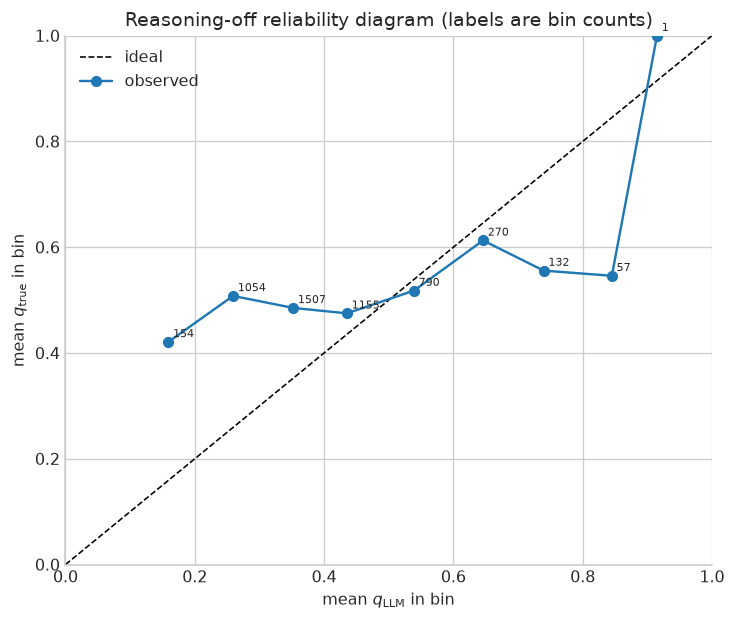

In [12]:
fig, axis = plt.subplots(figsize=(6.5, 5.5))
bin_count = 10
bins = defaultdict(list)
for row in calibration_rows:
    index = min(int(row["q_llm"] * bin_count), bin_count - 1)
    bins[index].append(row)

predicted_means = [fmean(row["q_llm"] for row in bins[index]) for index in sorted(bins)]
target_means = [fmean(row["q_true"] for row in bins[index]) for index in sorted(bins)]
counts = [len(bins[index]) for index in sorted(bins)]
axis.plot([0, 1], [0, 1], "--", color="black", linewidth=1, label="ideal")
axis.plot(predicted_means, target_means, "o-", color="tab:blue", label="observed")
for x_value, y_value, count in zip(predicted_means, target_means, counts, strict=True):
    axis.annotate(
        str(count), (x_value, y_value), xytext=(3, 3),
        textcoords="offset points", fontsize=7,
    )
axis.set(
    xlim=(0, 1), ylim=(0, 1),
    xlabel=r"mean $q_{\mathrm{LLM}}$ in bin",
    ylabel=r"mean $q_{\mathrm{true}}$ in bin",
    title="Reasoning-off reliability diagram (labels are bin counts)",
)
axis.legend()
fig.tight_layout()
plt.show()

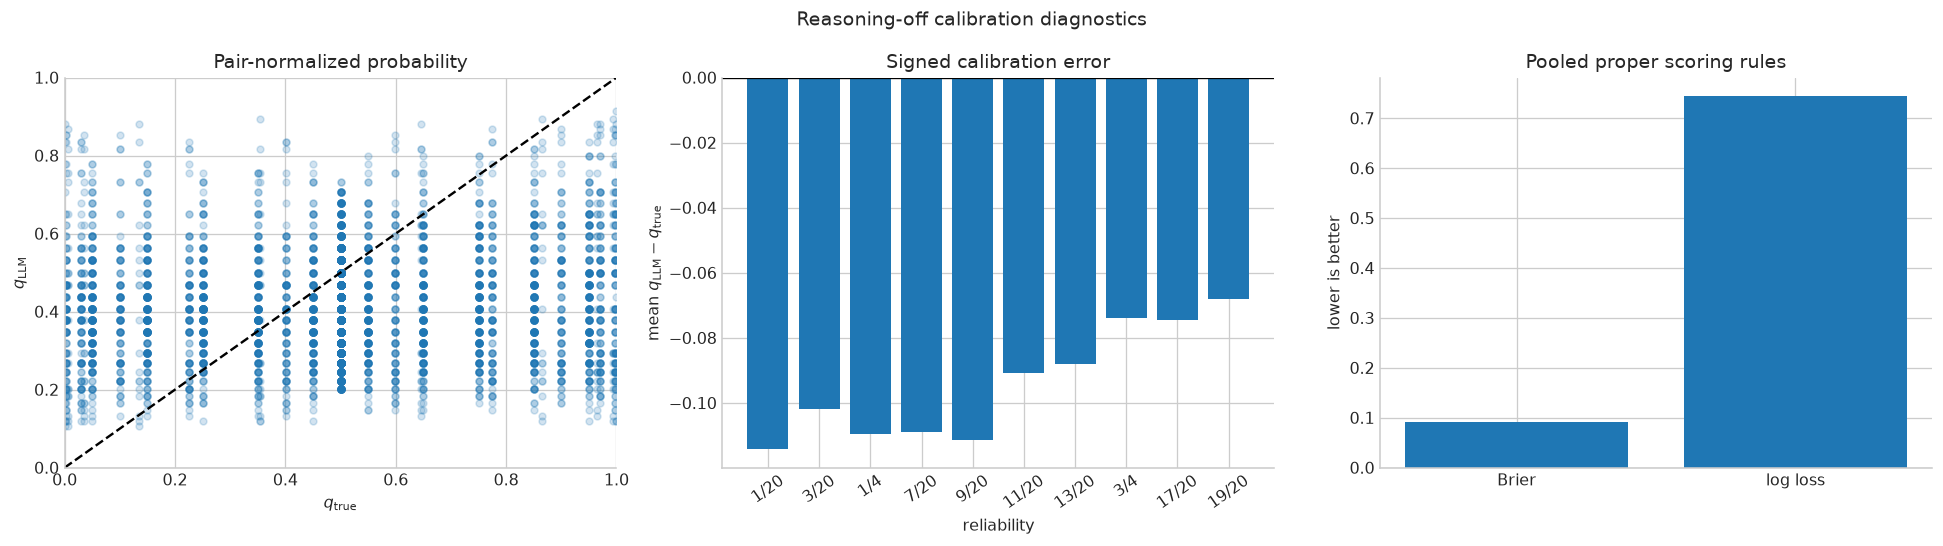

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].scatter(
    [row["q_true"] for row in calibration_rows],
    [row["q_llm"] for row in calibration_rows],
    s=18, alpha=0.20, color="tab:blue",
)
axes[0].plot([0, 1], [0, 1], "--", color="black")
axes[0].set(
    xlim=(0, 1), ylim=(0, 1),
    xlabel=r"$q_{\mathrm{true}}$",
    ylabel=r"$q_{\mathrm{LLM}}$",
    title="Pair-normalized probability",
)

mean_errors = []
for reliability_exact in reliability_order:
    rows = [
        row for row in calibration_rows
        if row["reliability_exact"] == reliability_exact
    ]
    mean_errors.append(fmean(row["calibration_error"] for row in rows))
axes[1].bar(range(len(reliability_order)), mean_errors, color="tab:blue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(len(reliability_order)), reliability_order, rotation=35)
axes[1].set(
    xlabel="reliability",
    ylabel=r"mean $q_{\mathrm{LLM}}-q_{\mathrm{true}}$",
    title="Signed calibration error",
)

pooled = calibration_summaries[0]
metric_names = ["brier_score", "log_loss"]
axes[2].bar(
    range(len(metric_names)), [pooled[name] for name in metric_names],
    color="tab:blue",
)
axes[2].set_xticks(range(len(metric_names)), ["Brier", "log loss"])
axes[2].set(title="Pooled proper scoring rules", ylabel="lower is better")

fig.suptitle("Reasoning-off calibration diagnostics")
fig.tight_layout()
plt.show()

## 6. Emitted-choice and boundary-logit behavior

The following tables keep the generated answer separate from the answer-boundary argmax. Tied Bayesian targets remain unscored instead of being assigned an arbitrary correct answer.

In [14]:
display(explorer.sql("""
SELECT
    reliability_exact,
    model_choice_canonical AS emitted_choice,
    logit_choice,
    COUNT(*) AS n,
    SUM(canonical_posterior_correct IS NOT NULL) AS emitted_scored,
    AVG(canonical_posterior_correct) AS emitted_accuracy,
    SUM(logit_correct IS NOT NULL) AS logit_scored,
    AVG(logit_correct) AS logit_accuracy
FROM transcript_rows
GROUP BY reliability_exact, reliability, model_choice_canonical, logit_choice
ORDER BY reliability, emitted_choice, logit_choice
"""))

display(explorer.sql("""
SELECT
    CASE
        WHEN agreement_difference > 0 THEN 'agreement favors C1'
        WHEN agreement_difference < 0 THEN 'agreement favors C2'
        ELSE 'agreement tie'
    END AS agreement_direction,
    model_choice_canonical AS emitted_choice,
    COUNT(*) AS n,
    AVG(z) AS mean_z,
    AVG(q_llm) AS mean_q_llm
FROM transcript_rows
GROUP BY agreement_direction, emitted_choice
ORDER BY agreement_direction, emitted_choice
"""))

reliability_exact,emitted_choice,logit_choice,n,emitted_scored,emitted_accuracy,logit_scored,logit_accuracy
1/20,C1,C1,79,62,0.0967741935483871,62,0.0967741935483871
1/20,C1,C2,6,4,0.25,4,0.75
1/20,C1,TIE,13,7,0.2857142857142857,7,0.7142857142857143
1/20,C2,C2,406,257,0.3852140077821012,257,0.3852140077821012
1/20,C2,TIE,8,6,0.8333333333333334,6,0.8333333333333334
3/20,C1,C1,81,63,0.1111111111111111,63,0.1111111111111111
3/20,C1,C2,9,6,0.16666666666666666,6,0.8333333333333334
3/20,C1,TIE,22,14,0.21428571428571427,14,0.7857142857142857
3/20,C2,C2,398,251,0.3745019920318725,251,0.3745019920318725
3/20,C2,TIE,2,2,1.0,2,1.0


agreement_direction,emitted_choice,n,mean_z,mean_q_llm
agreement favors C1,C1,843,0.48798932384341637,0.6116743382372493
agreement favors C1,C2,837,-0.40232974910394265,0.4024585367840242
agreement favors C2,C1,99,0.2702020202020202,0.5660626693200989
agreement favors C2,C2,1581,-0.8604522454142948,0.30458669202313476
agreement tie,C1,316,0.25,0.5608976747767056
agreement tie,C2,1444,-0.615564404432133,0.353703486098551


## 7. Conditional reasoning-off selection audits

These reproduce notebook 14's two separate exploration queries on the new transcript set. Selection means the actual generated `model_choice_canonical`. `matching_outputs` is also the number of distinct evidence scenarios here because this run has exactly one presentation per scenario.

Each detail table includes question membership, answer pattern, reliability, agreement vectors and totals, likelihoods, posteriors, \(q_{true}\), \(q_{LLM}\), calibration metrics, raw logits, logit-implied choice, emitted choice, and correctness.

In [15]:
SELECTION_AUDIT_COLUMNS = """
    row_id,
    positional_control_pair_id,
    question_set_index,
    question_subsets_json AS question_membership,
    observed_reports_json AS observed_answers,
    answer_pattern,
    reliability_exact,
    reliability,
    presentation_order,
    candidate_1,
    candidate_2,
    candidate_1_agreements_json,
    candidate_2_agreements_json,
    total_agreement_candidate_1,
    total_agreement_candidate_2,
    agreement_difference,
    candidate_1_likelihood_total,
    candidate_2_likelihood_total,
    candidate_1_posterior,
    candidate_2_posterior,
    total_marginalized_probability,
    q_true,
    candidate_1_raw_logit,
    candidate_2_raw_logit,
    z,
    q_llm,
    q_llm - q_true AS calibration_error,
    ABS(q_llm - q_true) AS absolute_calibration_error,
    (q_llm - q_true) * (q_llm - q_true) AS brier_score,
    CASE
        WHEN q_true IS NULL OR q_llm IS NULL THEN NULL
        ELSE -(
            q_true * LN(MIN(MAX(q_llm, 1e-12), 1.0 - 1e-12))
            + (1.0 - q_true)
              * LN(1.0 - MIN(MAX(q_llm, 1e-12), 1.0 - 1e-12))
        )
    END AS log_loss,
    logit_choice,
    logit_correct,
    model_choice_canonical AS emitted_choice,
    canonical_posterior_correct AS emitted_choice_correct,
    strict_answer_compliance,
    answer_boundary_available
"""


def selection_audit(condition_sql: str) -> tuple[SQLResult, SQLResult]:
    predicate = f"reasoning = 0 AND ({condition_sql})"
    counts = explorer.sql(f"""
        SELECT
            COUNT(*) AS matching_outputs,
            COUNT(DISTINCT positional_control_pair_id)
                AS distinct_evidence_scenarios,
            COUNT(DISTINCT question_set_index) AS represented_question_sets,
            SUM(answer_boundary_available) AS outputs_with_boundary_logits
        FROM transcript_rows
        WHERE {predicate}
    """)
    details = explorer.sql(f"""
        SELECT {SELECTION_AUDIT_COLUMNS}
        FROM transcript_rows
        WHERE {predicate}
        ORDER BY
            reliability, question_set_index, answer_pattern_index, presentation_order
    """)
    return counts, details

### 7.1 \(r>0.5\), agreement(C1) > agreement(C2), but C2 was emitted

In [16]:
high_reliability_c2_counts, high_reliability_c2_outputs = selection_audit(
    "reliability > 0.5 "
    "AND total_agreement_candidate_1 > total_agreement_candidate_2 "
    "AND model_choice_canonical = 'C2'"
)
display(high_reliability_c2_counts)
display(high_reliability_c2_outputs)

matching_outputs,distinct_evidence_scenarios,represented_question_sets,outputs_with_boundary_logits
335,335,38,335


row_id,positional_control_pair_id,question_set_index,question_membership,observed_answers,answer_pattern,reliability_exact,reliability,presentation_order,candidate_1,candidate_2,candidate_1_agreements_json,candidate_2_agreements_json,total_agreement_candidate_1,total_agreement_candidate_2,agreement_difference,candidate_1_likelihood_total,candidate_2_likelihood_total,candidate_1_posterior,candidate_2_posterior,total_marginalized_probability,q_true,candidate_1_raw_logit,candidate_2_raw_logit,z,q_llm,calibration_error,absolute_calibration_error,brier_score,log_loss,logit_choice,logit_correct,emitted_choice,emitted_choice_correct,strict_answer_compliance,answer_boundary_available
7b4872b5a95d93703530ce0d,3983c7432269e0dddf73e31f,3,"[[1,2,6,7],[3,4,5,7],[2,4,5,8]]","[""YES"",""NO"",""YES""]",YNY,11/20,0.55,C1_C2,2,7,"[1,1,1]","[1,0,0]",3,1,2,0.16637500000000005,0.11137499999999999,0.14970194578787538,0.10021369924642898,0.12348611111111112,0.599009900990099,22.625,22.875,-0.25,0.4378234991142019,-0.1611864018758971,0.1611864018758971,0.025981056149698208,0.7256918951263682,C2,0,C2,0,1,1
4cd2c2ca41e9dfa909c16419,6e36dec0d339d52f55149ef9,5,"[[2,5,6,7],[4,5,7,9],[2,4,5,8]]","[""YES"",""NO"",""YES""]",YNY,11/20,0.55,C1_C2,2,7,"[1,1,1]","[1,0,0]",3,1,2,0.16637500000000005,0.11137499999999999,0.14970194578787538,0.10021369924642898,0.12348611111111112,0.599009900990099,22.5,23.0,-0.5,0.37754066879814546,-0.22146923219195352,0.22146923219195352,0.04904862080769342,0.7735819346751561,C2,0,C2,0,1,1
ff0c8e24a312387ab092e40d,4a91f67bb9c88b703079ee10,8,"[[1,4,7,9],[1,7,8,9],[1,2,5,6]]","[""YES"",""NO"",""YES""]",YNY,11/20,0.55,C1_C2,2,7,"[0,1,1]","[1,0,0]",2,1,1,0.136125,0.11137499999999999,0.12309257375381485,0.10071210579857579,0.122875,0.55,22.25,23.25,-1.0,0.2689414213699951,-0.28105857863000494,0.28105857863000494,0.07899392462151866,0.8632616875182229,C2,0,C2,0,1,1
6858234ea0db23819023965c,052156106b1af8f3eca94d1f,8,"[[1,4,7,9],[1,7,8,9],[1,2,5,6]]","[""NO"",""YES"",""YES""]",NYY,11/20,0.55,C1_C2,2,7,"[1,0,1]","[0,1,0]",2,1,1,0.136125,0.11137499999999999,0.12309257375381485,0.10071210579857579,0.122875,0.55,22.75,23.0,-0.25,0.4378234991142019,-0.11217650088579817,0.11217650088579817,0.012583567350981477,0.7134394198788435,C2,0,C2,0,1,1
5913f471cb1a1d7adcca172e,dd4abd330b880b0432e1a5f4,9,"[[3,5,8,9],[2,5,7,8],[2,4,5,8]]","[""YES"",""YES"",""YES""]",YYY,11/20,0.55,C1_C2,2,7,"[0,1,1]","[0,1,0]",2,1,1,0.136125,0.11137499999999999,0.12413085603556366,0.101561609483643,0.12184722222222222,0.55,22.5,23.0,-0.5,0.37754066879814546,-0.17245933120185458,0.17245933120185458,0.029742220918590974,0.7490769841801066,C2,0,C2,0,1,1
76093a677bcf2ea6c8ffca9e,0d6e4faeb923b6f5135d4b4d,9,"[[3,5,8,9],[2,5,7,8],[2,4,5,8]]","[""YES"",""NO"",""YES""]",YNY,11/20,0.55,C1_C2,2,7,"[0,0,1]","[0,0,0]",1,0,1,0.11137499999999999,0.09112499999999997,0.10071210579857579,0.08240081383519837,0.122875,0.55,22.5,22.875,-0.375,0.4073334000459302,-0.14266659995406983,0.14266659995406983,0.020353758742454597,0.72937326413984,C2,0,C2,0,1,1
cdf2a9825b0b89963ad88ac8,0f6493422d12c53da3f2f674,9,"[[3,5,8,9],[2,5,7,8],[2,4,5,8]]","[""NO"",""YES"",""YES""]",NYY,11/20,0.55,C1_C2,2,7,"[1,1,1]","[1,1,0]",3,2,1,0.16637500000000005,0.136125,0.14909824129046712,0.12198947014674583,0.12398611111111112,0.55,22.5,22.875,-0.375,0.4073334000459302,-0.14266659995406983,0.14266659995406983,0.020353758742454597,0.72937326413984,C2,0,C2,0,1,1
40bd7cfc9da320896de09484,d74a5f65e14542a42f208bd2,9,"[[3,5,8,9],[2,5,7,8],[2,4,5,8]]","[""NO"",""NO"",""YES""]",NNY,11/20,0.55,C1_C2,2,7,"[1,0,1]","[1,0,0]",2,1,1,0.136125,0.11137499999999999,0.12029161603888214,0.09842041312272175,0.1257361111111111,0.55,22.5,22.75,-0.25,0.4378234991142019,-0.11217650088579817,0.11217650088579817,0.012583567350981477,0.7134394198788435,C2,0,C2,0,1,1
c40e7d629fb4129aa5ecb95e,5182840fccf6623027b4f4eb,10,"[[2,6,7,9],[1,3,5,9],[1,2,4,6]]","[""NO"",""YES"",""YES""]",NYY,11/20,0.55,C1_C2,2,7,"[0,0,1]","[0,0,0]",1,0,1,0.1113749999999999

### 7.2 \(r<0.5\), agreement(C2) > agreement(C1), but C1 was emitted

In [17]:
low_reliability_c1_counts, low_reliability_c1_outputs = selection_audit(
    "reliability < 0.5 "
    "AND total_agreement_candidate_2 > total_agreement_candidate_1 "
    "AND model_choice_canonical = 'C1'"
)
display(low_reliability_c1_counts)
display(low_reliability_c1_outputs)

matching_outputs,distinct_evidence_scenarios,represented_question_sets,outputs_with_boundary_logits
41,41,9,41


row_id,positional_control_pair_id,question_set_index,question_membership,observed_answers,answer_pattern,reliability_exact,reliability,presentation_order,candidate_1,candidate_2,candidate_1_agreements_json,candidate_2_agreements_json,total_agreement_candidate_1,total_agreement_candidate_2,agreement_difference,candidate_1_likelihood_total,candidate_2_likelihood_total,candidate_1_posterior,candidate_2_posterior,total_marginalized_probability,q_true,candidate_1_raw_logit,candidate_2_raw_logit,z,q_llm,calibration_error,absolute_calibration_error,brier_score,log_loss,logit_choice,logit_correct,emitted_choice,emitted_choice_correct,strict_answer_compliance,answer_boundary_available
6c0d8719d9911c38a91b149e,df13f3133ac9085a6f2e3829,6,"[[4,7,8,9],[1,7,8,9],[4,7,8,9]]","[""NO"",""YES"",""YES""]",NYY,1/20,0.05,C1_C2,2,7,"[1,0,0]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.1919191919191919,0.010101010101010102,0.026125,0.95,22.75,22.875,-0.125,0.46879062662624377,-0.4812093733737562,0.4812093733737562,0.2315624610227631,0.751349035317169,C2,0,C1,1,1,1
a36ae2ae244f4fbcc62df19d,017e783ee66240f31717ab59,14,"[[4,7,8,9],[1,5,7,8],[1,2,4,6]]","[""YES"",""NO"",""NO""]",YNN,1/20,0.05,C1_C2,2,7,"[0,1,0]","[1,0,1]",1,2,-1,0.045125,0.0023750000000000004,0.04501808205511909,0.0023693727397431103,0.111375,0.9500000000000001,22.75,22.75,0.0,0.5,-0.45000000000000007,0.45000000000000007,0.20250000000000007,0.6931471805599453,TIE,0,C1,1,1,1
080315e512c1c1a9d8b60a7a,7821ed1aa334fa586488fbef,14,"[[4,7,8,9],[1,5,7,8],[1,2,4,6]]","[""NO"",""YES"",""NO""]",NYN,1/20,0.05,C1_C2,2,7,"[1,0,0]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.04501808205511909,0.0023693727397431103,0.111375,0.9500000000000001,23.25,22.75,0.5,0.6224593312018546,-0.3275406687981455,0.3275406687981455,0.10728288971673643,0.4990769841801066,C1,1,C1,1,1,1
bb299bf076f0a80af4e15d61,6f247c94f1be3bc4042174fa,16,"[[1,6,7,9],[4,6,7,8],[1,2,6,9]]","[""NO"",""YES"",""NO""]",NYN,1/20,0.05,C1_C2,2,7,"[1,0,0]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.02489826884612732,0.0013104352024277536,0.201375,0.95,22.875,22.625,0.25,0.5621765008857981,-0.3878234991142019,0.3878234991142019,0.15040706646518334,0.5884394198788437,C1,1,C1,1,1,1
a8ffa1593a09763953950b1d,ee2999856de22145ec24ca8c,33,"[[3,4,6,7],[3,5,7,9],[1,4,6,7]]","[""NO"",""YES"",""YES""]",NYY,1/20,0.05,C1_C2,2,7,"[1,0,0]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.1919191919191919,0.010101010101010102,0.026125,0.95,23.0,22.625,0.375,0.5926665999540697,-0.3573334000459303,0.3573334000459303,0.12768715878838485,0.5418732641398402,C1,1,C1,1,1,1
9bebfeb7305031b9e03df256,250ca8aaa49c6c48b04063e9,50,"[[1,2,5,6],[3,7,8,9],[1,2,5,8]]","[""YES"",""YES"",""NO""]",YYN,1/20,0.05,C1_C2,2,7,"[1,0,0]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.1919191919191919,0.010101010101010102,0.026125,0.95,22.625,22.625,0.0,0.5,-0.44999999999999996,0.44999999999999996,0.20249999999999996,0.6931471805599453,TIE,0,C1,1,1,1
580217a66dbbfb1e61fcd15f,296543d89b5824c08b0e31fe,50,"[[1,2,5,6],[3,7,8,9],[1,2,5,8]]","[""NO"",""NO"",""NO""]",NNN,1/20,0.05,C1_C2,2,7,"[0,1,0]","[1,0,1]",1,2,-1,0.045125,0.0023750000000000004,0.2373438527284681,0.012491781722550954,0.021125,0.9500000000000001,23.0,22.375,0.625,0.6513548646660542,-0.2986451353339459,0.2986451353339459,0.08918891685863085,0.45995067827651864,C1,1,C1,1,1,1
67e31d26d43094a7d68f0f60,900784485dc6dffc8842e566,60,"[[2,6,7,9],[4,7,8,9],[1,4,8,9]]","[""NO"",""YES"",""NO""]",NYN,1/20,0.05,C1_C2,2,7,"[0,0,1]","[0,1,1]",1,2,-1,0.045125,0.0023750000000000004,0.2345679012345679,0.012345679012345678,0.021375,0.95,23.0,22.625,0.375,0.5926665999540697,-0.3573334000459303,0.3573334000459303,0.12768715878838485,0.5418732641398402,C1,1,C1,1,1,1
9513acd4380f9344e62598d0,1a2ae0a5c4193bef629ee560,62,"[[1,2,5,7],[3,4,7,8],[1,4,7,9]]","[""NO"",""YES"",""YES""]",NYY,1/20,0.05,C1_C2,2,7,"[0,0,0]","[0,1,1]",0,2,-2,0.8573749999999999,0.0023750000000000004,0.4724805400564855,0.001308810360267273,0.201625,0.9972375690

## Further exploration recipes

All result objects are ordinary Python dictionaries as well as SQL rows. The source artifact remains read-only; use `inspect_transcript(row_id, include_prompt=True)` to open any exact prompt and completion.

In [18]:
# Question schedules with the most emitted-choice errors.
display(explorer.sql("""
SELECT
    question_set_index,
    reliability_exact,
    COUNT(*) AS scored_rows,
    SUM(canonical_posterior_correct = 0) AS emitted_choice_errors,
    AVG(ABS(q_llm - q_true)) AS mean_absolute_calibration_error,
    AVG(ABS(z)) AS mean_absolute_logit_contrast
FROM transcript_rows
WHERE canonical_posterior_correct IS NOT NULL
GROUP BY question_set_index, reliability_exact, reliability
HAVING COUNT(*) >= 5
ORDER BY emitted_choice_errors DESC, mean_absolute_calibration_error DESC
LIMIT 30
"""))

# A narrow condition query; edit values or selected columns freely.
display(
    explorer.query("transcript_rows")
    .select(
        "row_id",
        "question_set_index",
        "answer_pattern",
        "question_subsets_json",
        "observed_reports_json",
        "candidate_1_posterior",
        "candidate_2_posterior",
        "q_true",
        "z",
        "q_llm",
        "model_choice_canonical",
        "canonical_posterior_correct",
    )
    .where_eq(reliability_exact="19/20", reasoning=False)
    .where("question_set_index IN (?, ?)", 0, 1)
    .sort("question_set_index", "answer_pattern_index")
    .run()
)

question_set_index,reliability_exact,scored_rows,emitted_choice_errors,mean_absolute_calibration_error,mean_absolute_logit_contrast
44,1/20,8,8,0.5779513738961823,0.546875
6,1/4,8,8,0.4856304862095526,0.8125
44,3/20,8,8,0.47740627403987945,0.546875
6,7/20,8,8,0.39828824226975856,0.890625
44,1/4,8,8,0.3868209976095758,0.59375
44,7/20,8,8,0.28664385479015453,0.59375
6,9/20,8,8,0.265919854282948,0.890625
1,7/20,8,8,0.21858657615155158,0.28125
44,9/20,8,8,0.1866438547901545,0.59375
1,9/20,8,8,0.12248774782327113,0.296875


row_id,question_set_index,answer_pattern,question_subsets_json,observed_reports_json,candidate_1_posterior,candidate_2_posterior,q_true,z,q_llm,model_choice_canonical,canonical_posterior_correct
5b2ad9b4d2b0c9091d39e718,0,YYY,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""YES"",""YES"",""YES""]",0.1956639566395664,0.0005420054200542005,0.9972375690607735,0.375,0.5926665999540697,C1,1
34592aaa8de0b515721ad366,0,YYN,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""YES"",""YES"",""NO""]",0.0013403880070546738,0.0013403880070546738,0.5,0.0,0.5,C2,None
c93173df329f56618b927feb,0,YNY,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""YES"",""NO"",""YES""]",0.891358024691358,0.0024691358024691358,0.9972375690607735,0.125,0.5312093733737563,C1,1
39205ea30dd019be4bb13246,0,YNN,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""YES"",""NO"",""NO""]",0.041565918249856074,0.041565918249856074,0.5,-0.625,0.34864513533394575,C2,None
793c071dab98bf65c5067c37,0,NYY,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""NO"",""YES"",""YES""]",0.0013403880070546738,0.0013403880070546738,0.5,-1.125,0.24508501313237172,C2,None
deae2b535fbd00029b3f1305,0,NYN,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""NO"",""YES"",""NO""]",0.00045351473922902497,0.163718820861678,0.0027624309392265197,-1.125,0.24508501313237172,C2,1
535ff9cd9d672f658f036f36,0,NNY,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""NO"",""NO"",""YES""]",0.041565918249856074,0.041565918249856074,0.5,-1.25,0.22270013882530884,C2,None
96734362fb72f117543a97d2,0,NNN,"[[2,5,6,9],[1,4,6,9],[1,2,3,4]]","[""NO"",""NO"",""NO""]",0.00130718954248366,0.4718954248366013,0.0027624309392265192,-1.875,0.13296424019782924,C2,1
51be24a3026b7c368b8646d9,1,YYY,"[[1,2,3,5],[1,2,7,9],[3,4,6,9]]","[""YES"",""YES"",""YES""]",0.2373438527284681,0.012491781722550954,0.9500000000000001,0.625,0.6513548646660542,C1,1
1ec9512b144d410f1fcc1104,1,YYN,"[[1,2,3,5],[1,2,7,9],[3,4,6,9]]","[""YES"",""YES"",""NO""]",0.47306710807641905,0.02489826884612732,0.95,0.625,0.6513548646660542,C1,1
